# Solve large-scale Maximum Independent Set problems using Fire Opal
**Apply graph reduction techniques and Fire Opal's QAOA solver to large-scale MIS problems**

The Maximum Independent Set (MIS) problem is a fundamental combinatorial optimization problem with the objective of selecting the largest subset of non-adjacent nodes in a graph. It has broad applicability across diverse fields, such as network design, resource allocation, scheduling, wireless communication, and computational biology. For example, in wireless networks, finding a MIS can help identify the maximum number of transmitters that can operate simultaneously without interference. A closely related formulation is the [Maximum Weight Independent Set (MWIS) problem](https://docs.q-ctrl.com/fire-opal/apply/solve-maximum-weight-independent-set-problems-using-fire-opal), where vertices have weights and the goal is to maximize the total weight of the selected independent set.

This application note describes how to solve a large-scale MIS problem instance from the [QOBLIB benchmark library](https://git.zib.de/qopt/qoblib-quantum-optimization-benchmarking-library), a collection of optimization problems used to test quantum algorithms. Since the benchmark problem (186 vertices) exceeds current quantum hardware capabilities, you will apply classical graph reduction techniques to reduce the problem size before quantum optimization. Specifically, this application note covers:

- An introduction to the Maximum Independent Set problem
- Graph reduction techniques for handling large-scale problems 
- Execution of Fire Opal's QAOA solver for the reduced problem
- Solution reconstruction and validation

## 1. Introduction
### 1.1 Problem definition
An MIS instance is defined by an undirected graph $G = (V, E)$ where $V$ is the set of vertices and $E$ is the set of edges. The goal is to find the largest subset $S \subseteq V$ such that no two vertices in $S$ share an edge, this is called an independent set. The MIS problem is NP-hard, meaning no polynomial-time algorithm is known for solving it exactly. This makes approximate and heuristic approaches particularly valuable, and quantum computing presents a promising opportunity for generating high-quality solutions.

To solve MIS using QAOA, you can formulate it as an optimization problem. For a graph with $n$ vertices, you will assign a binary variable $x_i \in \{0, 1\}$ to each vertex, where $x_i = 1$ indicates vertex $i$ is in the independent set. The cost function to minimize is:

$$C(x) = -\sum_{i \in V} x_i + P \sum_{(i,j) \in E} x_i x_j$$

The first term rewards including vertices (minimizing the negative maximizes the count), while the second term penalizes selecting adjacent vertices with weight $P$. When $P$ is sufficiently large, any optimal solution will be a valid independent set.

### 1.2 Graph reduction strategies

When the number of vertices exceeds available qubits, graph reduction techniques become essential. These techniques systematically simplify the graph while preserving information needed to reconstruct the optimal solution.

**Degree-based reduction:** Vertices with degree 0 or 1 can be handled optimally without quantum computation:
- Degree-0 vertices (isolated) are always included in the maximum independent set
- For degree-1 vertices (pendant), it is always optimal to include the pendant and exclude its single neighbor

**Vertex folding:** For a degree-2 vertex $v$ with non-adjacent neighbors $u$ and $w$, we "fold" these three vertices into a single new vertex $x$. In the solution:
- If $x$ is selected → both $u$ and $w$ are in the MIS (and $v$ is not)
- If $x$ is not selected → $v$ is in the MIS (and $u$, $w$ are not)

These reductions are applied iteratively until no further simplification is possible.

### 1.3 Using Fire Opal's QAOA solver

Fire Opal's `solve_qaoa` function simplifies running QAOA by handling all aspects of execution-parameter optimization, error suppression, and circuit compilation with a single function call. To use `solve_qaoa`, you only need to provide either a graph or a polynomial cost function. 

For the MIS problem, the cost polynomial is constructed directly from the graph structure, with terms for vertex inclusion rewards and edge violation penalties.

## 2. Imports and initialization

The following section sets up the necessary imports and helper functions.

In [1]:
import fireopal as fo
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import os
from sympy import symbols, Poly, Float, symarray
import qctrlvisualizer as qv

plt.style.use(qv.get_qctrl_style())
QCTRL_STYLE_COLORS = qv.QCTRL_STYLE_COLORS

### 2.1 Graph reduction functions

You can define functions for graph reduction that systematically simplify the problem while tracking information needed to reconstruct the full solution.

In [2]:
def graph_reduction_procedure(graph, nodes_to_add_total, nodes_to_remove_total):
    """
    Apply the graph reduction procedure:
    While there exists a vertex v with degree 0 or 1:
        - If deg(v) == 1, add v to the independent set and remove v and its neighbor
        - If deg(v) == 0, add v to the independent set and remove v
    """
    graph_reduction = graph.copy()
    min_deg = min(dict(graph_reduction.degree()).values())
    while min_deg <= 1:
        degrees = dict(graph_reduction.degree())
        sorted_degrees = sorted(degrees.items(), key=lambda x: x[0], reverse=True)
        nodes_to_add = [node for node, deg in sorted_degrees if deg == 1]
        nodes_to_remove = [list(graph_reduction[node])[0] for node in nodes_to_add]
        nodes_to_add += [node for node, deg in sorted_degrees if deg == 0]
        graph_reduction.remove_nodes_from(nodes_to_add)
        graph_reduction.remove_nodes_from(nodes_to_remove)
        nodes_to_add_total.extend(nodes_to_add)
        nodes_to_remove_total.extend(nodes_to_remove)
        min_deg = min(dict(graph_reduction.degree()).values())
    return graph_reduction


def fold_vertices(G, total_nodes):
    """
    Apply the folding rule for vertices of degree 2:
    If v has degree 2 and its neighbors u, w are not adjacent,
    fold (v, u, w) into a new vertex 'x_v'.
    """
    G = G.copy()
    folded = {}
    linked_folds = {}
    for v in list(G.nodes()):
        # Skip if vertex was removed during folding
        if v not in G:
            continue
        nbrs = list(G.neighbors(v))
        if len(nbrs) == 2:
            u, w = nbrs
            # Check if u and w are not adjacent
            if not G.has_edge(u, w) and u not in folded and w not in folded:
                # Create the new folded vertex name
                new_v = total_nodes + 1
                new_neighbors = (set(G.neighbors(u)) | set(G.neighbors(w))) - {v, u, w}
                G.add_node(new_v)
                for n in new_neighbors:
                    G.add_edge(new_v, n)
                G.remove_nodes_from([v, u, w])
                folded[new_v] = (v, u, w)
                linked_folds[v] = new_v
                linked_folds[u] = new_v
                linked_folds[w] = new_v
                total_nodes += 1
    return G, folded, linked_folds

### 2.2 Helper functions

Define additional functions for graph analysis, file parsing, and cost polynomial construction.

In [3]:
def analyze_graph_structure(graph):
    """Analyze key properties of the graph to inform reduction strategies."""
    print("Graph Analysis:")
    print(f"   Vertices: {len(graph.nodes)}")
    print(f"   Edges: {len(graph.edges)}")
    print(f"   Density: {nx.density(graph):.4f}")
    print(
        f"   Average degree: {sum(dict(graph.degree()).values()) / len(graph.nodes):.2f}"
    )
    degrees = [d for n, d in graph.degree()]
    print(f"   Degree range: {min(degrees)} - {max(degrees)}")
    components = list(nx.connected_components(graph))
    print(f"   Connected components: {len(components)}")
    if len(components) > 1:
        component_sizes = [len(c) for c in components]
        print(f"   Component sizes: {sorted(component_sizes, reverse=True)}")
    return {
        "vertices": len(graph.nodes),
        "edges": len(graph.edges),
        "density": nx.density(graph),
        "avg_degree": sum(degrees) / len(degrees),
        "max_degree": max(degrees),
        "min_degree": min(degrees),
        "components": len(components),
    }


def parse_gph_file(filepath):
    """
    Parse a .gph file (DIMACS graph format) into a NetworkX graph.
    """
    graph = nx.Graph()
    if not filepath or not os.path.exists(filepath):
        print("File not found. Please check the path or download manually.")
        return None
    with open(filepath, "r") as f:
        lines = f.readlines()
    print(f"Parsing {len(lines)} lines...")
    for line_num, line in enumerate(lines, 1):
        line = line.strip()
        if not line or line.startswith("c"):
            continue
        elif line.startswith("p edge"):
            parts = line.split()
            if len(parts) >= 4:
                graph.add_nodes_from(range(1, int(parts[2]) + 1))
        elif line.startswith("e"):
            parts = line.split()
            if len(parts) >= 3:
                try:
                    graph.add_edge(int(parts[1]), int(parts[2]))
                except ValueError:
                    print(f"Warning: Could not parse edge on line {line_num}: {line}")
        else:
            print(f"Warning: Unknown line format on line {line_num}: {line}")
    print(f"Successfully parsed graph:")
    print(f"   - Vertices: {len(graph.nodes)}")
    print(f"   - Edges: {len(graph.edges)}")
    print(f"   - Density: {nx.density(graph):.3f}")
    return graph


def mis_to_cost_polynomial(graph, penalty=2):
    """
    Convert an MIS problem to a cost polynomial for Fire Opal's QAOA solver.
    """
    node_to_idx = {node: i for i, node in enumerate(graph.nodes())}
    variables = symarray("x", len(graph.nodes()))
    cost = Float(0)
    for node in graph.nodes():
        cost -= variables[node_to_idx[node]]
    for u, v in graph.edges():
        cost += penalty * variables[node_to_idx[u]] * variables[node_to_idx[v]]
    return cost, variables, node_to_idx


def draw_graph(graph, selected_nodes=None, title=""):
    """
    Visualize the graph with optional highlighting of selected nodes.
    """
    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(graph, seed=42)
    if selected_nodes:
        colors = [
            QCTRL_STYLE_COLORS[0] if n in selected_nodes else QCTRL_STYLE_COLORS[2]
            for n in graph.nodes()
        ]
    else:
        colors = QCTRL_STYLE_COLORS[2]
    nx.draw(
        graph,
        pos,
        node_color=colors,
        edge_color="gray",
        node_size=100,
        alpha=0.8,
        with_labels=False,
    )
    plt.title(title)
    plt.show()

## 3. Setting up the problem

You will use the `es60fst02` instance from the QOBLIB benchmark library, a 186-vertex graph that exceeds current quantum hardware capabilities, making it an ideal test case for graph reduction techniques.

### 3.1 Setting up credentials for Fire Opal

To use Fire Opal within your local development environment you need an [IBM Quantum account](https://quantum.cloud.ibm.com/). Set up Fire Opal with your IBM account information and choose a backend.

In [ ]:
# Set credentials.
# The Fire Opal QAOA solver needs an IBM Cloud account with access to IBM Sessions execution mode,
# which is not available to Open Plan users. To use the solver, you must have a paid IBM Quantum plan.
# See here for details: https://quantum.cloud.ibm.com/docs/en/guides/execution-modes#session-mode
# and here for plans: https://www.ibm.com/quantum/pricing
token = "YOUR_IBM_CLOUD_API_KEY"
instance = "YOUR_IBM_CRN"

credentials = fo.credentials.make_credentials_for_ibm_cloud(
    token=token, instance=instance
)

Q-CTRL authentication successful!


In [ ]:
# Replace with the name of the device you wish to use.
# Run fo.show_supported_devices(credentials) to get a list of supported backend names.
backend_name = "your_desired_backend"

### 3.2 Loading the benchmark graph

Let's parse the QOBLIB graph file and analyze its structure.

In [ ]:
import requests
import os
import tempfile

qoblib_url = "https://git.zib.de/qopt/qoblib-quantum-optimization-benchmarking-library/-/raw/main/07-independentset/instances/es60fst02.gph"


def download_qoblib_instance(url, filename=None):
    """
    Download a QOBLIB instance from the given URL.
    """
    if filename is None:
        # Extract filename from URL
        filename = url.split("/")[-1].split("?")[0]
    print(f"Downloading {filename} from QOBLIB...")

    try:
        response = requests.get(url, timeout=30)
        response.raise_for_status()
        current_dir = os.getcwd()
        filepath = os.path.join(current_dir, filename)
        with open(filepath, "wb") as f:
            f.write(response.content)

        print(f"Downloaded successfully to: {filepath}")
        print(f"File size: {len(response.content)} bytes")
        return filepath
    except requests.exceptions.RequestException as e:
        print(f"Download failed: {e}")
        print("Alternative: You can manually download from:")
        print(f"   {url}")
        print("   and place it in the same directory as this notebook")
        return None


downloaded_file = download_qoblib_instance(qoblib_url)

G = parse_gph_file(downloaded_file)
original_stats = analyze_graph_structure(G)

Downloaded successfully to: d:\Dropbox\PC\Documents\Documents_Drive\Github-Code\qctrl\notebooks\fire-opal\apply\es60fst02.gph
File size: 2558 bytes
Parsing 282 lines...
Successfully parsed graph:
   - Vertices: 186
   - Edges: 280
   - Density: 0.016
Graph Analysis:
   Vertices: 186
   Edges: 280
   Density: 0.0163
   Average degree: 3.01
   Degree range: 1 - 4
   Connected components: 1


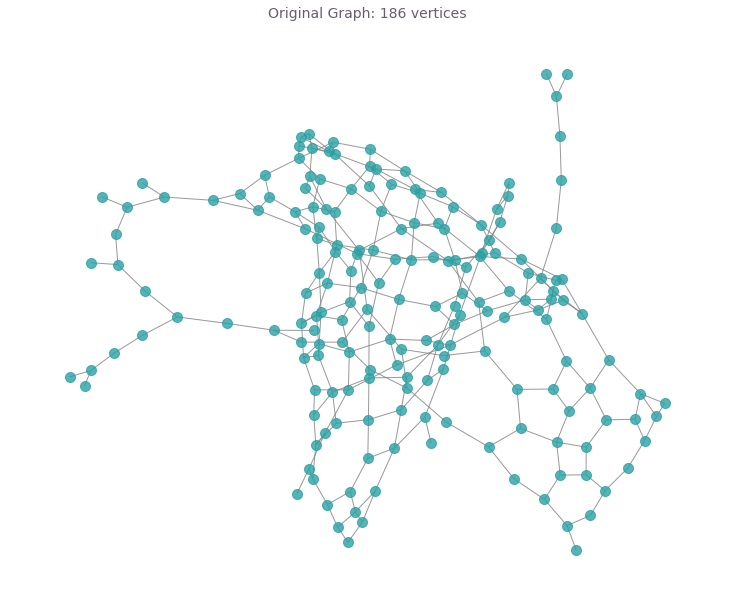

In [5]:
draw_graph(G, title=f"Original Graph: {len(G.nodes)} vertices")

### 3.3 Applying graph reduction

Apply degree-based reduction and vertex folding to reduce the problem size while preserving the ability to reconstruct the full solution.

In [8]:
# Track vertices for solution reconstruction
nodes_to_add_total = []
nodes_to_remove_total = []

# Apply degree-based reduction
g_reduced = graph_reduction_procedure(G, nodes_to_add_total, nodes_to_remove_total)

print(f"After degree-based reduction:")
print(f"   Remaining vertices: {len(g_reduced.nodes)}")
print(f"   Vertices in MIS: {len(nodes_to_add_total)}")
print(f"   Vertices excluded: {len(nodes_to_remove_total)}")

# Analyze the reduced graph
reduced_stats = analyze_graph_structure(g_reduced)

After degree-based reduction:
   Remaining vertices: 144
   Vertices in MIS: 23
   Vertices excluded: 22
Graph Analysis:
   Vertices: 144
   Edges: 228
   Density: 0.0221
   Average degree: 3.17
   Degree range: 2 - 4
   Connected components: 1


Graph Analysis:
   Vertices: 52
   Edges: 84
   Density: 0.0633
   Average degree: 3.23
   Degree range: 2 - 4
   Connected components: 1


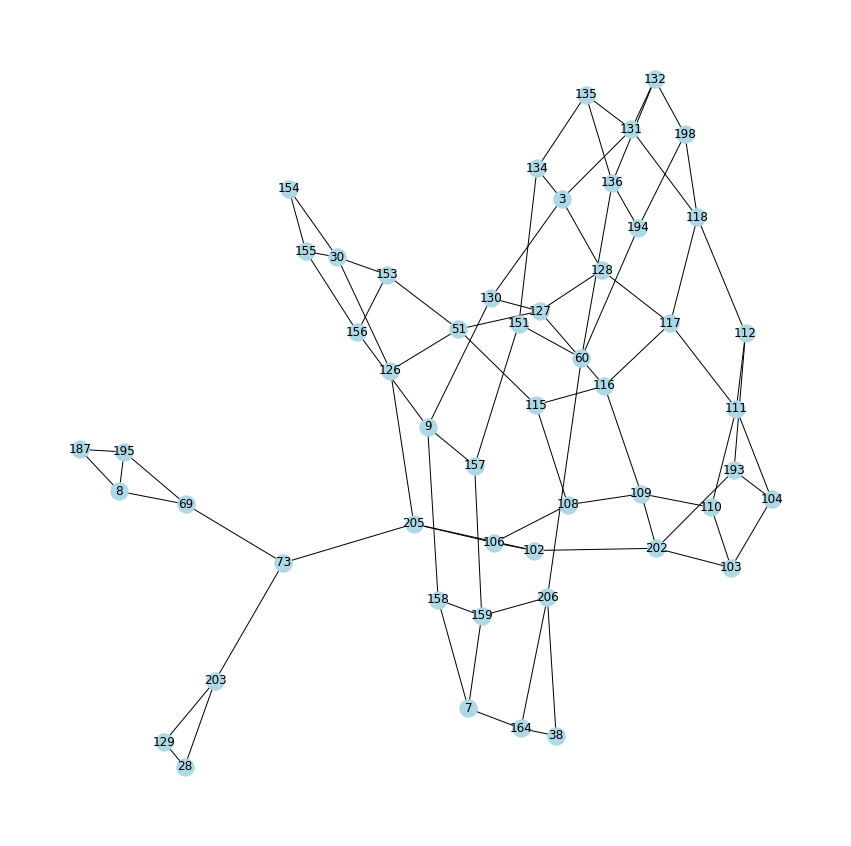

In [27]:
# Apply vertex folding
g_fold = g_reduced.copy()
max_nodes = max(G.nodes())
folds_total = []
linked_folds_total = []
ii = 0
while True:
    g_fold_nodes = g_fold.number_of_nodes()
    g_fold, folds, linked_folds = fold_vertices(g_fold, max_nodes)
    folds_total.append(folds)
    linked_folds_total.append(linked_folds)
    degrees = dict(g_fold.degree())
    sorted_degrees = sorted(degrees.items(), key=lambda x: x[1], reverse=True)
    nodes_to_remove = [node for node, deg in sorted_degrees if deg > 4]
    nodes_to_remove_total += nodes_to_remove
    g_fold.remove_nodes_from(nodes_to_remove)
    g_fold = graph_reduction_procedure(
        g_fold, nodes_to_add_total, nodes_to_remove_total
    )
    max_nodes = max(g_fold.nodes())
    ii += 1
    if g_fold.number_of_nodes() == g_fold_nodes:
        break

pos = nx.spring_layout(
    g_fold, k=0.3, iterations=50
)  # try larger k: 0.5, 0.8, 1.0, etc.
fig, ax = plt.subplots(figsize=(15, 15))
nx.draw(g_fold, with_labels=True, node_color="lightblue", ax=ax)

folding_stats = analyze_graph_structure(g_fold)

### 3.4 Constructing the cost function

In this case you will construct the cost polynomial for the reduced graph, which Fire Opal's QAOA solver will minimize.

In [12]:
mapping = {old: new for new, old in enumerate(sorted(g_fold.nodes()))}
g_fold_mapped = nx.relabel_nodes(g_fold, mapping)
reverse_mapping = {new: old for old, new in mapping.items()}
cost_polynomial, variables, node_to_idx = mis_to_cost_polynomial(g_fold_mapped)

print(f"Cost polynomial created for {len(g_fold_mapped.nodes())} variables")

Cost polynomial created for 52 variables


## 4. Running the algorithm

Execute Fire Opal's QAOA solver on the reduced MIS problem.

In [15]:
fire_opal_job = fo.solve_qaoa(
    problem=cost_polynomial, credentials=credentials, backend_name=backend_name
)

This function performs multiple consecutive runs. Wait time may vary depending on hardware queues.



You can check the status of the job and retrieve results when complete.

In [31]:
fire_opal_job.status()

{'status_message': 'Job has finished successfully.',
 'action_status': 'SUCCESS'}

In [15]:
fire_opal_result = fire_opal_job.result()

In [16]:
reduced_solution = fire_opal_result["solution_bitstring"]
print(f"Solution for reduced graph: {reduced_solution}")
print(f"Vertices selected in reduced graph: {reduced_solution.count('1')}")

Solution for reduced graph: 0000001100000001110101000011100101010001110001011111
Vertices selected in reduced graph: 22


## 5. Reconstructing the full solution

You need to reverse the reduction operations to obtain the solution for the original 186-vertex graph.

In [17]:
def cost_mis(x, G):
    """Calculate MIS cost with penalty for edge violations."""
    penalty = 0
    for i, j in G.edges:
        if x[i] + x[j] == "11":
            penalty += 10
    return -x.count("1") + penalty


def bitflip_improvement(x0, G, max_iterations=10):
    """
    Perform iterative bitflip improvement until no improvement is found.
    """
    change = {"0": "1", "1": "0"}
    nq = len(x0)
    best_string = x0

    for iteration in range(max_iterations):
        previous_cost = cost_mis(best_string, G)
        improved = False

        for spin_to_flip in range(nq):
            new_string = (
                best_string[:spin_to_flip]
                + change[best_string[spin_to_flip]]
                + best_string[spin_to_flip + 1 :]
            )
            new_cost = cost_mis(new_string, G)
            if new_cost < previous_cost:
                best_string = new_string
                previous_cost = new_cost
                improved = True

        if not improved:
            break

    return best_string


def reconstruct_full_solution(
    reduced_bitstring,
    original_graph,
    reduced_graph,
    nodes_to_add_total,
    nodes_to_remove_total,
    folds_total,
    linked_folds_total=None,
    variables_to_bitstring_index_map=None,
    apply_bitflip=True,
):
    """
    Reconstruct the full MIS solution from the reduced graph solution.
    """
    sorted_nodes = sorted(reduced_graph.nodes())
    sol_dict = {}

    if variables_to_bitstring_index_map is not None:
        for i, qubit in enumerate(sorted_nodes):
            var_name = f"x_{i}"
            bit_idx = variables_to_bitstring_index_map[var_name]
            sol_dict[qubit] = int(reduced_bitstring[bit_idx])
    else:
        mapping = {old: new for new, old in enumerate(sorted_nodes)}
        for qubit in reduced_graph.nodes():
            sol_dict[qubit] = int(reduced_bitstring[mapping[qubit]])
    for qubit in nodes_to_remove_total:
        sol_dict[qubit] = 0
    for qubit in nodes_to_add_total:
        sol_dict[qubit] = 1
    if linked_folds_total is None:
        linked_folds_total = [{}] * len(folds_total)

    for folds, linked_folds in zip(reversed(folds_total), reversed(linked_folds_total)):
        for qubit in folds.keys():
            decision = sol_dict[qubit]
            if decision:
                for q in folds[qubit]:
                    if q == folds[qubit][1] or q == folds[qubit][2]:
                        sol_dict[q] = 1
                    else:
                        sol_dict[q] = 0
            else:
                for q in folds[qubit]:
                    if q == folds[qubit][0]:
                        sol_dict[q] = 1
                    else:
                        sol_dict[q] = 0

    sol_final = "".join(
        [str(sol_dict[qubit]) for qubit in sorted(original_graph.nodes())]
    )

    if apply_bitflip:
        mapping_full = {
            old: new for new, old in enumerate(sorted(original_graph.nodes()))
        }
        G_relabeled = nx.relabel_nodes(original_graph, mapping_full)
        sol_final = bitflip_improvement(sol_final, G_relabeled)

    return sol_final


def process_fire_opal_results(
    fire_opal_result,
    original_graph,
    reduced_graph,
    nodes_to_add_total,
    nodes_to_remove_total,
    folds_total,
    linked_folds_total=None,
    verbose=True,
):
    """
    Process Fire Opal QAOA results and find best MIS solution.
    """
    samples = fire_opal_result["final_bitstring_distribution"]
    var_map = fire_opal_result["variables_to_bitstring_index_map"]

    mapping_full = {old: new for new, old in enumerate(sorted(original_graph.nodes()))}
    G_relabeled = nx.relabel_nodes(original_graph, mapping_full)

    cost_list = {}
    cost_count_dict = {}

    for bitstring, count in samples.items():
        sol_final = reconstruct_full_solution(
            reduced_bitstring=bitstring,
            original_graph=original_graph,
            reduced_graph=reduced_graph,
            nodes_to_add_total=nodes_to_add_total,
            nodes_to_remove_total=nodes_to_remove_total,
            folds_total=folds_total,
            linked_folds_total=linked_folds_total,
            variables_to_bitstring_index_map=var_map,
            apply_bitflip=True,
        )

        cost_i = cost_mis(sol_final, G_relabeled)
        cost_list[cost_i] = sol_final

        if cost_i in cost_count_dict:
            cost_count_dict[cost_i] += count
        else:
            cost_count_dict[cost_i] = count

        if verbose:
            print(
                f"Cost: {cost_i} | Independent set size: {sol_final.count('1')} | bitstring: {sol_final}"
            )

    best_cost = min(cost_list.keys())
    best_solution = cost_list[best_cost]

    return best_solution, cost_list, cost_count_dict


best_solution, cost_list, cost_count_dict = process_fire_opal_results(
    fire_opal_result=fire_opal_result,
    original_graph=G,
    reduced_graph=g_fold,
    nodes_to_add_total=nodes_to_add_total,
    nodes_to_remove_total=nodes_to_remove_total,
    folds_total=folds_total,
    linked_folds_total=linked_folds_total,
    verbose=True,
)

Cost: -87 | Independent set size: 87 | bitstring: 011101111101111111001011001110101111110101011000010001101100000010100010101100000010111000110111000101010010100101101001010111100001001010110010100011111100000001100101011000010000000000
Cost: -86 | Independent set size: 86 | bitstring: 011101111101111111001011001110101111110101011000010001101100000010100010101100000010111000110111000101010011010001000101010111100001001010110010100011111100000001100101011000010000000000
Cost: -86 | Independent set size: 86 | bitstring: 011101111101111111001011001110101111110101011000010001101100000010100010101100000010111000110111000101010010100001100101010111100001001010110010100011111100000001100101011000010000000000
Cost: -86 | Independent set size: 86 | bitstring: 011101111101111111001011001010101111110101011000010001101100000010100010101100000010111000110111000101010010100001100101010111101001001010110010100011111100000001100101011000010000000000
Cost: -86 | Independent set size: 86 | bitstring: 01

## 6. Validating the solution

After reconstruction, you must verify that your solution is actually a valid independent set, meaning no two selected vertices share an edge.

In [19]:
# Validate the solution
selected_vertices = {i + 1 for i, bit in enumerate(best_solution) if bit == "1"}

# Check for edge violations
violations = [
    (u, v) for u, v in G.edges() if u in selected_vertices and v in selected_vertices
]

print(f"Solution validation:")
print(f"   Valid independent set: {len(violations) == 0}")
print(f"   Edge violations: {len(violations)}")
print(f"   Independent set size: {best_solution.count('1')}")
print(f"   Known optimal size: 88")
print(f"   Solution quality: {100 * best_solution.count('1') / 88:.1f}% of optimal")

Solution validation:
   Valid independent set: True
   Edge violations: 0
   Independent set size: 88
   Known optimal size: 88
   Solution quality: 100.0% of optimal


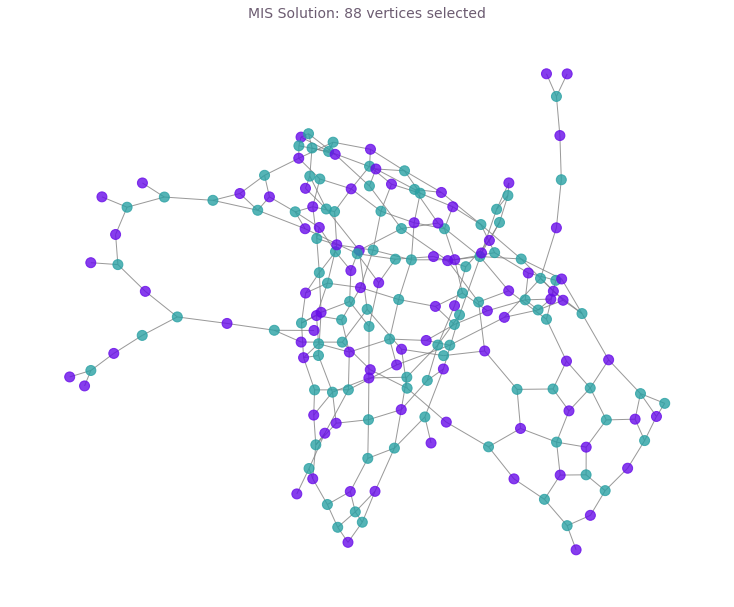

In [20]:
# Visualize the solution
draw_graph(
    G,
    selected_nodes=selected_vertices,
    title=f"MIS Solution: {best_solution.count('1')} vertices selected",
)

### 6.1 Analyzing the bitstring distribution

You can also examine the distribution of solutions returned by Fire Opal to understand the quality of the QAOA optimization.

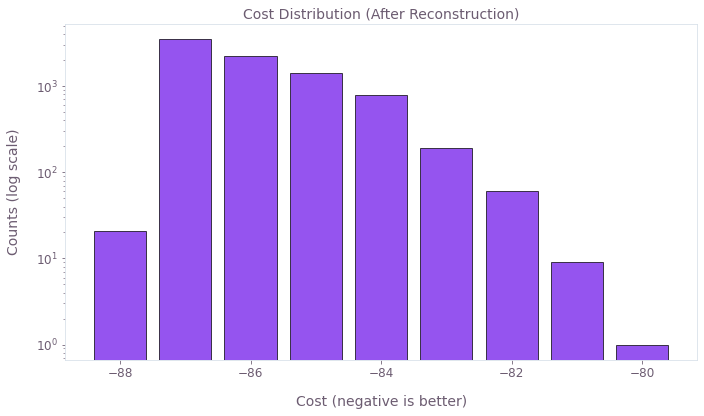

Best cost: -88 (MIS size: 88)
Best solution found 21 times out of 8192 samples


In [21]:
def plot_cost_distribution_reconstructed(
    cost_count_dict, title="Cost Distribution (After Reconstruction)"
):
    """Plot the cost distribution after reconstruction."""
    cost_values = sorted(cost_count_dict.keys())
    counts = [cost_count_dict[c] for c in cost_values]

    fig, ax = plt.subplots(figsize=(10, 6))
    plt.bar(
        cost_values,
        counts,
        width=0.8,
        edgecolor="black",
        alpha=0.7,
        color=QCTRL_STYLE_COLORS[0],
    )
    ax.set_yscale("log")
    ax.set_xlabel("Cost (negative is better)")
    ax.set_ylabel("Counts (log scale)")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

    # Print summary
    best_cost = min(cost_count_dict.keys())
    total_samples = sum(cost_count_dict.values())
    best_count = cost_count_dict[best_cost]
    print(f"Best cost: {best_cost} (MIS size: {-best_cost})")
    print(f"Best solution found {best_count} times out of {total_samples} samples")


plot_cost_distribution_reconstructed(cost_count_dict)

The Fire Opal's `solve_qaoa` solver successfully delivered a high-quality solution to this large-scale QOBLIB benchmark instance. By iteratively applying degree-based rules and vertex folding reductions, you compressed the benchmark graph that is beyond today’s hardware limits into a smaller, QAOA-ready instance. After running Fire Opal’s optimized QAOA workflow on the reduced problem, you reconstructed a solution for the original graph and validated that it forms a true independent set. The same methodology can be extended to even larger graphs, while Fire Opal provides a streamlined and robust execution layer that helps you focus on problem formulation and results rather than low-level hardware details.

For more information on Fire Opal's QAOA solver and its capabilities, see the [Fire Opal documentation](https://docs.q-ctrl.com/fire-opal/execute/run-algorithms/solve-optimization-problems/fire-opal-qaoa-solver).

The following package versions were used to produce this notebook.

In [23]:
fo.print_package_versions()

| Package               | Version |
| --------------------- | ------- |
| Python                | 3.12.11 |
| matplotlib            | 3.10.3  |
| networkx              | 3.2.1   |
| numpy                 | 2.3.0   |
| sympy                 | 1.14.0  |
| fire-opal             | 9.2.0   |
| qctrl-visualizer      | 9.0.0   |
| qctrl-workflow-client | 7.3.0   |
